In [1]:
# Test & demonstrate SPWL
from sympy import *
from matplotlib import cm
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import numpy as np

## SPWL order

In [16]:
# F(x,y) = sin(0.5*x*y)
def FFxy(x,y):
    return np.sin(.3*x*y)
(Nx, Ny)  = (4, 4)
x_mesh_fine = np.linspace(0, Nx, 100)
y_mesh_fine = np.linspace(0, Ny, 100)
X_fine, Y_fine = np.meshgrid(x_mesh_fine, y_mesh_fine)
FFxy_fine = FFxy(X_fine, Y_fine)
# np.set_printoptions(linewidth=200)
# print(FFxy_fine)
# print(FFxy_fine[0,2], FFxy_fine[1,1], FFxy_fine[1,2], FFxy_fine[9,9])

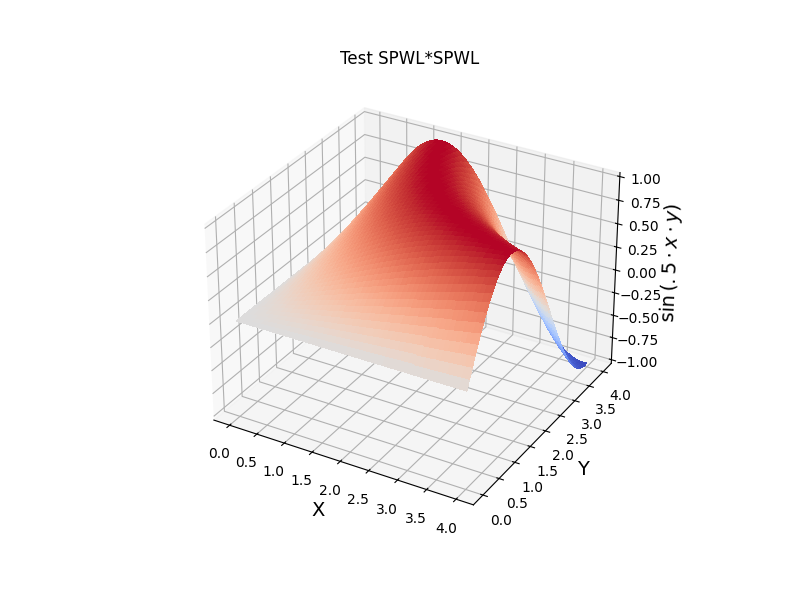

In [17]:
%matplotlib widget
figureSize = (8,6)
fig = plt.figure(figsize=figureSize)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_fine, Y_fine, FFxy_fine, cmap=cm.coolwarm, antialiased=False) # viridis plasma
# ax.plot_wireframe(X_fine, Y_fine, FFxy_fine, rstride=150, cstride=150)
ax.set_xlabel(r'X', fontsize=14)
ax.set_ylabel(r'Y', fontsize=14)
# ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'$\sin{\left(.5\cdot x\cdot y\right)}$', fontsize=14)
ax.set_title('Test SPWL*SPWL')
plt.show()

In [18]:
X = np.linspace(0, Nx, Nx+1)
Y = np.linspace(0, Ny, Ny+1)
print("X=", X)
print("Y=", Y)
XX, YY = np.meshgrid(X, Y)
F = FFxy(XX, YY)
eps = 0.01
print(F)

X= [0. 1. 2. 3. 4.]
Y= [0. 1. 2. 3. 4.]
[[ 0.          0.          0.          0.          0.        ]
 [ 0.          0.29552021  0.56464247  0.78332691  0.93203909]
 [ 0.          0.56464247  0.93203909  0.97384763  0.67546318]
 [ 0.          0.78332691  0.97384763  0.42737988 -0.44252044]
 [ 0.          0.93203909  0.67546318 -0.44252044 -0.99616461]]


## X потом Y

In [19]:
pyo.quicksum(F[2,j] for j in pyo.RangeSet(Ny-1, Ny))

1.6493108114293462

In [6]:
A = lambda i, j: F[i,j] - F[i-1,j]
def tFx(j: int, x):
    """
    Returns expression widetilde{F}_j(x) SPWL
    """
    if j < 0 or j > Ny:
        raise IndexError(f"tF(j,x), j={j} is out of range {0}:{Ny}")
    return (1/2)*(F[0,j] + A(1,j)*(x - X[0]) + F[Nx,j] + A(Nx,j)*(x - X[Nx])) + \
            (1/2)*pyo.quicksum((F[i,j] - 2*F[i-1,j] + F[i-2,j])*pyo.sqrt( (x - X[i-1])**2 + eps**2) for i in pyo.RangeSet(2, Nx))

tAx = lambda j, x: tFx(j, x) - tFx(j - 1, x)
def tFxy(x, y):
    return (1/2) * (tFx(0, x) + tAx(1,x) * (y - Y[0]) + tFx(Ny, x) + tAx(Ny,x) * (y - Y[Ny])) + \
           (1/2) * pyo.quicksum((tFx(j,x) - 2*tFx(j - 1, x) + tFx(j - 2, x))*pyo.sqrt((y - Y[j - 1]) ** 2 + eps ** 2) for j in pyo.RangeSet(2, Ny))

j, x = Ny, 4.
print(f"tFx({j},{x})={tFx(j,x)}")
x, y = 4., 4.
print(f"tFxy({x},{y})={tFxy(x,y)}")
print(X_fine.shape, Y_fine.shape)
print(tFxy(X_fine[150,150], Y_fine[150, 150]))
print(tFxy(X_fine[199,199], Y_fine[199, 199]))

tFx(3,4.0)=-0.11910202274670478
tFxy(4.0,4.0)=-1.2538770989603467
(200, 200) (200, 200)
0.9136258646155557
0.42732821142117716


In [20]:
v_tFxy = np.vectorize(tFxy)
tFxy_fine = v_tFxy(X_fine, Y_fine)

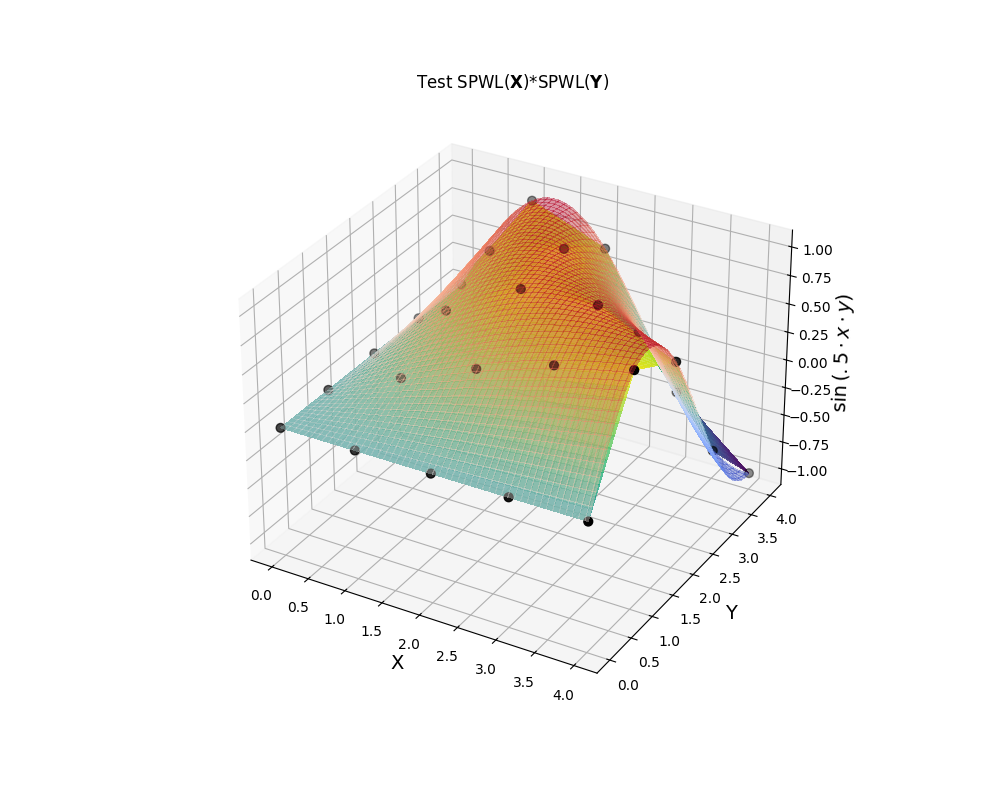

In [21]:
%matplotlib widget
figureSize = (10,8)
fig = plt.figure(figsize=figureSize)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_fine, Y_fine, FFxy_fine, cmap=cm.coolwarm, antialiased=False, alpha=0.4) # viridis plasma
ax.scatter(XX, YY, F, s=40, color='black', marker='o', label='F')
ax.plot_surface(X_fine, Y_fine, tFxy_fine, cmap=cm.viridis, antialiased=False, alpha=0.8) # viridis plasma
# ax.plot_wireframe(X_fine, Y_fine, FFxy_fine, rstride=150, cstride=150)
ax.set_xlabel(r'X', fontsize=14)
ax.set_ylabel(r'Y', fontsize=14)
# ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'$\sin{\left(.5\cdot x\cdot y\right)}$', fontsize=14)
ax.set_title(r'Test SPWL($\bf{X}$)*SPWL($\bf{Y}$)')
plt.show()

## Y then X

In [22]:
# A = lambda i, j: F[i,j] - F[i-1,j]
Ay = lambda i, j: F[i,j] - F[i,j-1]
def tFy(i: int, y):
    """
    Returns expression widetilde{F}_i(y) SPWL
    """
    if i < 0 or i > Nx:
        raise IndexError(f"tFy(i,y), i={i} is out of range {0}:{Nx}")
    # return (1/2)*(F[0,j] + A(1,j)*(x - X[0]) + F[Nx,j] + A(Nx,j)*(x - X[Nx])) + \
    #         (1/2)*pyo.quicksum((F[i,j] - 2*F[i-1,j] + F[i-2,j])*pyo.sqrt( (x - X[i-1])**2 + eps**2) for i in pyo.RangeSet(2, Nx))
    return (1/2)*(F[i,0] + Ay(i,1)*(y - Y[0]) + F[i,Ny] + Ay(i,Ny)*(y - Y[Ny])) + \
            (1/2)*pyo.quicksum((F[i,j] - 2*F[i,j-1] + F[i,j-2])*pyo.sqrt( (y - Y[j-1])**2 + eps**2) for j in pyo.RangeSet(2, Ny))

# tAx = lambda j, x: tFx(j, x) - tFx(j - 1, x)
tAy = lambda i, y: tFy(i, y) - tFy(i - 1, y)
def tFyx(x, y):
    # return (1/2) * (tFx(0, x) + tAx(1,x) * (y - Y[0]) + tFx(Ny, x) + tAx(Ny,x) * (y - Y[Ny])) + \
    #        (1/2) * pyo.quicksum((tFx(j,x) - 2*tFx(j - 1, x) + tFx(j - 2, x))*pyo.sqrt((y - Y[j - 1]) ** 2 + eps ** 2) for j in pyo.RangeSet(2, Ny))
    return (1/2) * (tFy(0, y) + tAy(1,y) * (x - X[0]) + tFy(Nx, y) + tAy(Nx,y) * (x - X[Nx])) + \
           (1/2) * pyo.quicksum((tFy(i,y) - 2*tFy(i - 1, y) + tFy(i - 2, y))*pyo.sqrt((x - X[i - 1]) ** 2 + eps ** 2) for i in pyo.RangeSet(2, Nx))

j, x = Ny, 4.
print(f"tFx({j},{x})={tFx(j,x)}")
i, y = Nx, 4.
print(f"tFy({i},{y})={tFy(i,y)}")

x, y = 4., 4.
print(f"tFxy({x},{y})={tFxy(x,y)}")
print(f"tFyx({x},{y})={tFyx(x,y)}")


tFx(4,4.0)=-0.9961711733286753
tFy(4,4.0)=-0.9961711733286753
tFxy(4.0,4.0)=-0.9961777372593668
tFyx(4.0,4.0)=-0.9961777372593668


In [23]:
v_tFyx = np.vectorize(tFyx)
tFyx_fine = v_tFyx(X_fine, Y_fine)

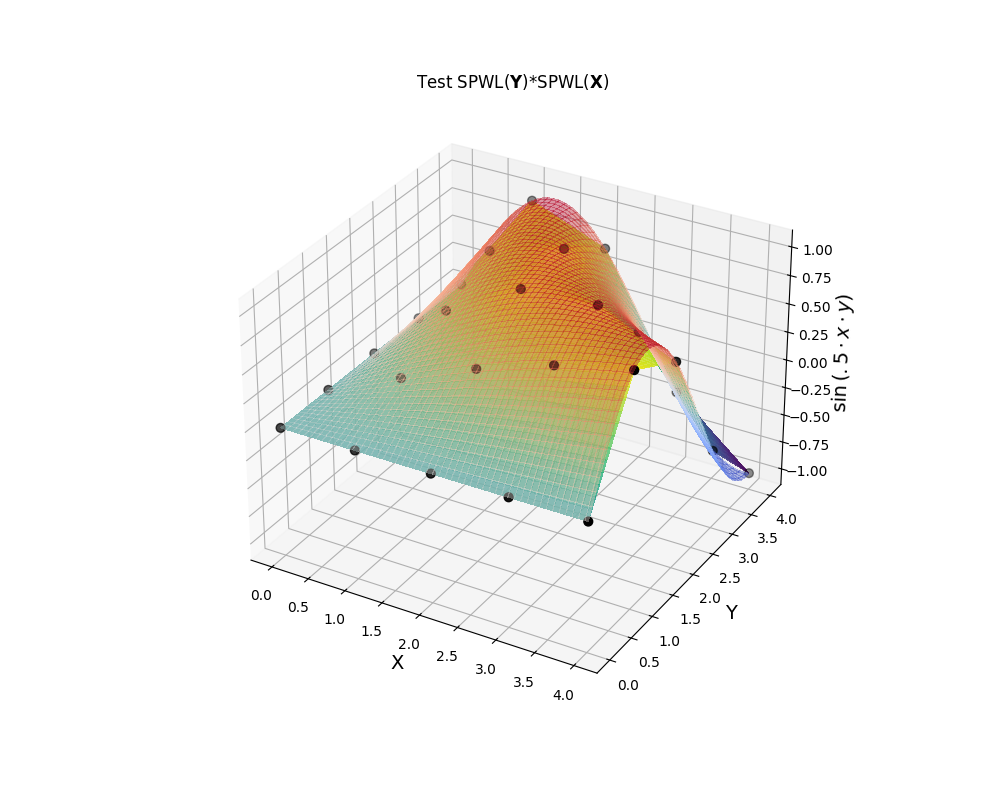

In [24]:
%matplotlib widget
figureSize = (10,8)
fig = plt.figure(figsize=figureSize)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_fine, Y_fine, FFxy_fine, cmap=cm.coolwarm, antialiased=False, alpha=0.4) # viridis plasma
ax.scatter(XX, YY, F, s=40, color='black', marker='o', label='F')
ax.plot_surface(X_fine, Y_fine, tFyx_fine, cmap=cm.viridis, antialiased=False, alpha=0.8) # viridis plasma
# ax.plot_wireframe(X_fine, Y_fine, FFxy_fine, rstride=150, cstride=150)
ax.set_xlabel(r'X', fontsize=14)
ax.set_ylabel(r'Y', fontsize=14)
# ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'$\sin{\left(.5\cdot x\cdot y\right)}$', fontsize=14)
ax.set_title(r'Test SPWL($\bf{Y}$)*SPWL($\bf{X}$)')
plt.show()

In [25]:
print("tFxy_fine.shape =", tFxy_fine.shape, "tFyx_fine.shape =", tFyx_fine.shape)
np.sum(np.abs(tFxy_fine - tFyx_fine))
# print(v_tFxy)
# print(v_tFyx)
# np.sum(nov_tFxy - v_tFyx)

tFxy_fine.shape = (100, 100) tFyx_fine.shape = (100, 100)


1.4524891053842716e-12

In [15]:
# import sympy as sp
# xs, ys = sp.symbols("xs, ys")
# tFyx(xs, ys)

## SOS2

In [9]:
# pwlF(x,y)
FxyMesh = np.array([[0, -1],[-2,4]])
FxyMesh[1,1]
def Fxy(la,mu):
    return mu*la*(FxyMesh[1,1] - FxyMesh[0,1] - FxyMesh[1,0] + FxyMesh[0,0]) + \
           la*(FxyMesh[1,0] - FxyMesh[0,0]) + mu*(FxyMesh[0,1] - FxyMesh[0,0]) + FxyMesh[0,0]

la = np.linspace(0, 1, 200)
mu = np.linspace(0, 1, 200)
LA, MU = np.meshgrid(la, mu)
FXY = Fxy(LA, MU)
FXY[int(la[0]), int(mu[0])]

0.0

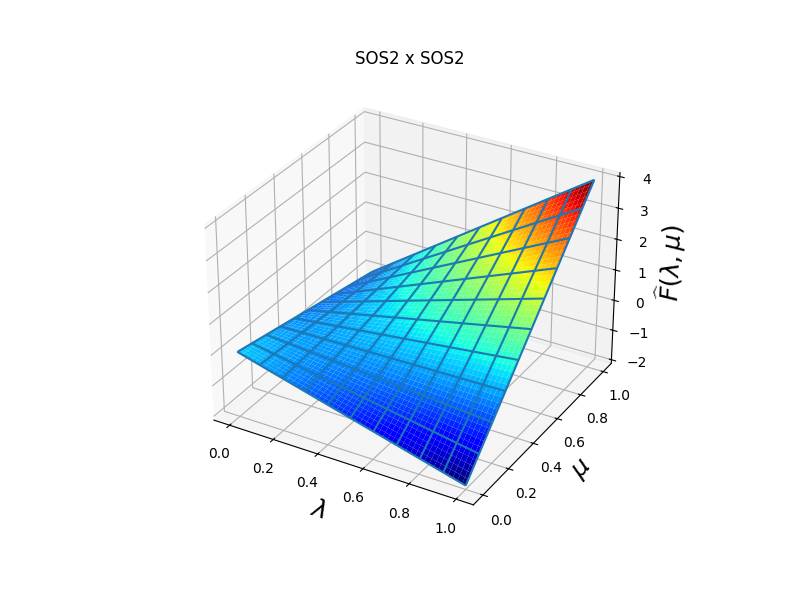

In [10]:
# to interact  with plot
%matplotlib widget

fig = plt.figure(figsize=figureSize)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(LA, MU, FXY, cmap='jet') # viridis plasma
ax.plot_wireframe(LA, MU, FXY, rstride=20, cstride=20)
ax.set_xlabel(r'$\lambda$', fontsize=18)
ax.set_ylabel(r'$\mu$', fontsize=18)
# ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'$\widehat{F}(\lambda, \mu)$', fontsize=18)
ax.set_title('SOS2 x SOS2')

plt.show()